In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sqlalchemy import create_engine 

In [38]:
username = "root"
password = "root"
host="localhost"
port = 3306
database = "healthcare_fraud_staging"
engine = create_engine(f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}")


In [39]:
query="""
select * from provider_summary """

df = pd.read_sql(query,engine)

In [40]:
df.head()

,provider,PotentialFraud,total_claims,total_patients,claims_per_patient,total_reimb,avg_reimb_per_patient,avg_length_ostay,readmitted,readm_rate,avg_chronic_disease
0,PRV56481,Yes,78.0,48,1.63,659000.0,13729.17,5.20,17.0,35.42,5.73
1,PRV51842,Yes,117.0,89,1.31,1165700.0,13097.75,4.96,24.0,26.97,5.02
2,PRV53762,Yes,84.0,59,1.42,915000.0,15508.47,6.58,15.0,25.42,5.59
3,PRV54692,Yes,48.0,38,1.26,371000.0,9763.16,4.73,9.0,23.68,4.97
4,PRV56007,Yes,69.0,55,1.25,833800.0,15160.00,6.03,13.0,23.64,5.16


In [41]:
df.shape

(317, 11)

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 317 entries, 0 to 316
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   provider               317 non-null    object 
 1   PotentialFraud         317 non-null    object 
 2   total_claims           317 non-null    float64
 3   total_patients         317 non-null    int64  
 4   claims_per_patient     317 non-null    float64
 5   total_reimb            317 non-null    float64
 6   avg_reimb_per_patient  317 non-null    float64
 7   avg_length_ostay       317 non-null    float64
 8   readmitted             317 non-null    float64
 9   readm_rate             317 non-null    float64
 10  avg_chronic_disease    317 non-null    float64
dtypes: float64(8), int64(1), object(2)
memory usage: 27.4+ KB


In [43]:
df.describe()

,total_claims,total_patients,claims_per_patient,total_reimb,avg_reimb_per_patient,avg_length_ostay,readmitted,readm_rate,avg_chronic_disease
count,317.000000,317.000000,317.000000,3.170000e+02,317.000000,317.000000,317.000000,317.000000,317.000000
mean,80.170347,71.208202,1.120442,8.063716e+05,11223.713281,5.595079,7.466877,9.992492,5.408107
std,58.438673,50.735235,0.086933,6.087220e+05,1725.783330,0.707592,7.690801,6.395864,0.340549
min,30.000000,30.000000,1.000000,2.100000e+05,6831.110000,3.080000,0.000000,0.000000,3.800000
25%,43.000000,39.000000,1.050000,4.220000e+05,10060.610000,5.100000,3.000000,4.840000,5.200000
50%,59.000000,54.000000,1.110000,6.100000e+05,11075.000000,5.600000,5.000000,9.520000,5.390000
75%,96.000000,87.000000,1.170000,9.620000e+05,12365.340000,6.030000,10.000000,14.810000,5.650000
max,516.000000,458.000000,1.630000,5.580870e+06,20117.650000,8.090000,63.000000,35.420000,6.360000


In [44]:
df["PotentialFraud"] = df["PotentialFraud"].map({"Yes":1,"No":0})

In [45]:
"""How many providers are labeled as Potential Fraud?
How many are Non-Fraud?
Is the dataset balanced or imbalanced?"""
fraud_counts=df["PotentialFraud"].value_counts()
print(fraud_counts)

PotentialFraud
1    211
0    106
Name: count, dtype: int64


In [46]:
df["fraud_label"]=df["PotentialFraud"].replace({1:"Potential Fraud",0:"Non-Fraud"})

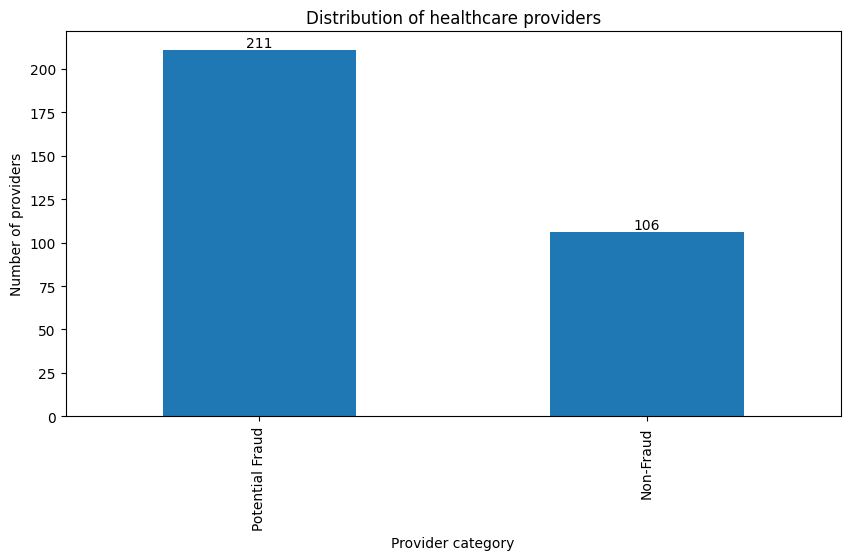

In [47]:
plt.figure(figsize=(10,5))
ax=df["fraud_label"].value_counts().plot(kind="bar")
plt.title("Distribution of healthcare providers")
plt.xlabel("Provider category")
plt.ylabel("Number of providers")

for container in ax.containers:
    ax.bar_label(container)
plt.show()

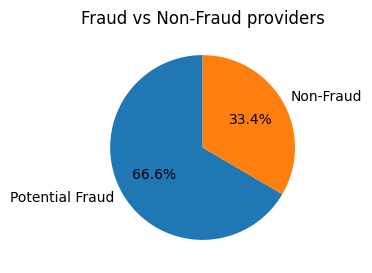

In [48]:
plt.figure(figsize=(3,3))
df["fraud_label"].value_counts().plot(kind="pie",autopct="%1.1f%%",startangle=90)
plt.ylabel("")
plt.title("Fraud vs Non-Fraud providers")
plt.show()

<Figure size 700x600 with 0 Axes>

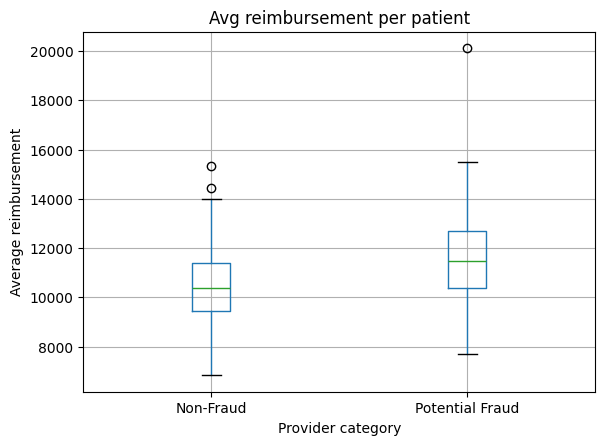

                 count          mean          std      min         25%  \
fraud_label                                                              
Non-Fraud        106.0  10505.517264  1607.656939  6831.11   9462.2175   
Potential Fraud  211.0  11584.513175  1672.793718  7685.71  10393.0400   

                      50%         75%       max  
fraud_label                                      
Non-Fraud        10375.01  11390.2775  15346.67  
Potential Fraud  11454.55  12693.8600  20117.65  


In [49]:
"""Do Potential Fraud providers receive higher reimbursement than Non-Fraud providers?"""

plt.figure(figsize=(7,6))

df.boxplot(column="avg_reimb_per_patient",by="fraud_label")
plt.title("Avg reimbursement per patient")
plt.suptitle("")
plt.xlabel("Provider category")
plt.ylabel("Average reimbursement")
plt.show()
print(df.groupby("fraud_label")["avg_reimb_per_patient"].describe())

<Figure size 600x500 with 0 Axes>

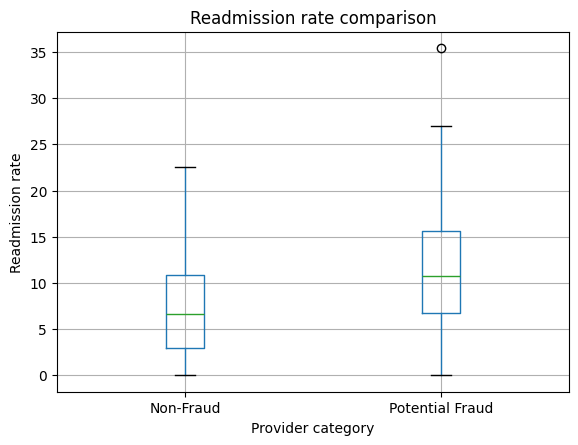

                 count       mean       std  min     25%     50%     75%  \
fraud_label                                                                
Non-Fraud        106.0   7.358585  5.668904  0.0  2.9625   6.625  10.905   
Potential Fraud  211.0  11.315687  6.342414  0.0  6.7400  10.780  15.630   

                   max  
fraud_label             
Non-Fraud        22.58  
Potential Fraud  35.42  


In [50]:
"""Do Potential Fraud providers have higher readmission rates than Non-Fraud providers?"""
plt.figure(figsize=(6,5))
df.boxplot(column="readm_rate",by="fraud_label")
plt.title("Readmission rate comparison")
plt.suptitle("")
plt.xlabel("Provider category")
plt.ylabel("Readmission rate")
plt.show()
print(df.groupby("fraud_label")["readm_rate"].describe())


<Figure size 600x500 with 0 Axes>

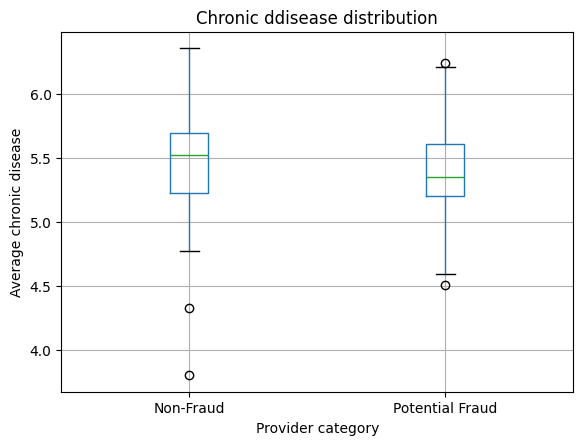

                 count      mean       std   min    25%   50%     75%   max
fraud_label                                                                
Non-Fraud        106.0  5.461792  0.389502  3.80  5.225  5.52  5.6975  6.36
Potential Fraud  211.0  5.381137  0.310598  4.51  5.200  5.35  5.6100  6.24


In [51]:
"""Do Potential Fraud providers treat patients with a higher average number of chronic diseases than Non-Fraud providers?"""
plt.figure(figsize=(6,5))
df.boxplot(column="avg_chronic_disease", by="fraud_label")
plt.title("Chronic ddisease distribution")
plt.suptitle("")
plt.xlabel("Provider category")
plt.ylabel("Average chronic disease")
plt.show()
print(df.groupby("fraud_label")["avg_chronic_disease"].describe())

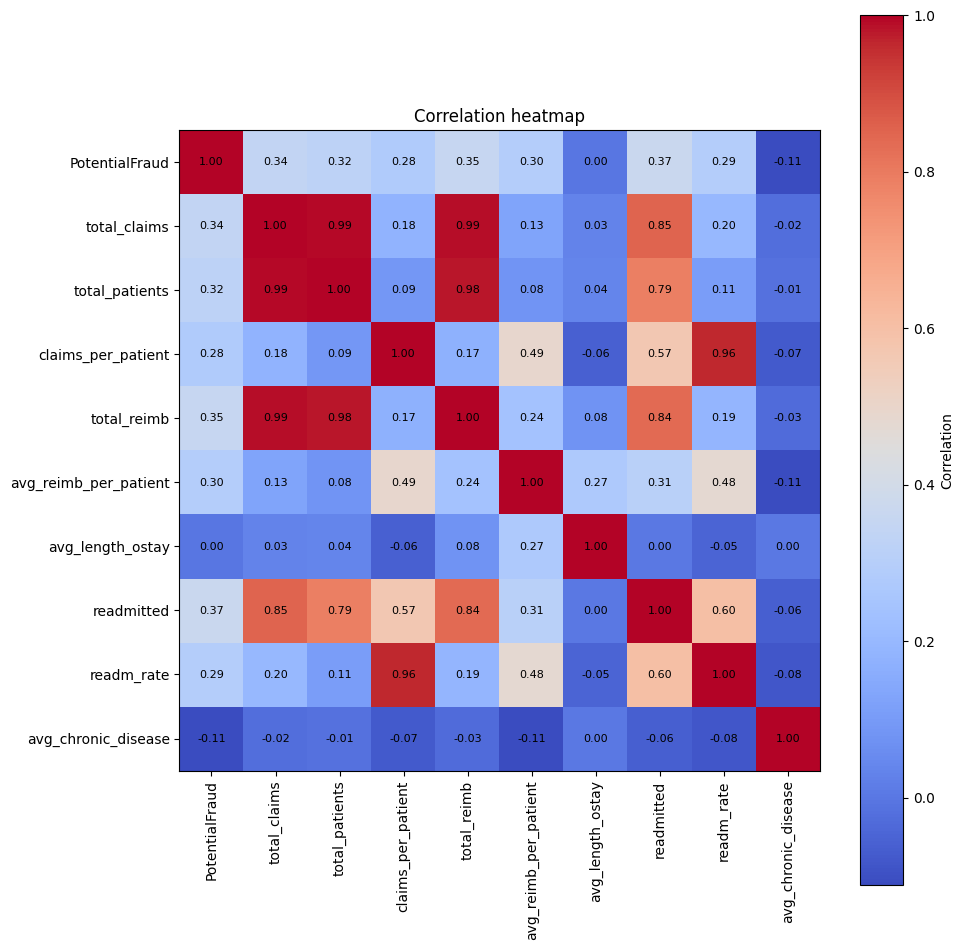

                       PotentialFraud  total_claims  total_patients  \
PotentialFraud               1.000000      0.341749        0.324603   
total_claims                 0.341749      1.000000        0.994140   
total_patients               0.324603      0.994140        1.000000   
claims_per_patient           0.280173      0.179951        0.089271   
total_reimb                  0.352914      0.987073        0.980983   
avg_reimb_per_patient        0.295430      0.127021        0.081932   
avg_length_ostay             0.000458      0.032366        0.037018   
readmitted                   0.366163      0.850283        0.790697   
readm_rate                   0.292347      0.196560        0.108594   
avg_chronic_disease         -0.111911     -0.022257       -0.013816   

                       claims_per_patient  total_reimb  avg_reimb_per_patient  \
PotentialFraud                   0.280173     0.352914               0.295430   
total_claims                     0.179951     0.987073  

In [52]:
import matplotlib.pyplot as plt
#calculate correlation matrix
corr_matrix=df.select_dtypes(include="number").corr()

#create fig
plt.figure(figsize=(10,10))

#display heatmap
plt.imshow(corr_matrix,cmap="coolwarm",interpolation="nearest")

#axis labels
plt.xticks(range(len(corr_matrix.columns)),corr_matrix.columns,rotation=90)
plt.yticks(range(len(corr_matrix.columns)),corr_matrix.columns)

#Add correlation values
for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix.columns)):
        plt.text(
            j,
            i,
            f"{corr_matrix.iloc[i,j]:.2f}",
            ha="center",
            va="center",
            fontsize=8,
            color="black"

        )

#color bar
plt.colorbar(label="Correlation")
plt.Text()
plt.title("Correlation heatmap")
plt.tight_layout()
plt.show()
print(corr_matrix)

In [53]:
x=df[["total_claims","total_patients","claims_per_patient","total_reimb","avg_reimb_per_patient",
    "avg_length_ostay","readmitted","readm_rate","avg_chronic_disease"]]
y=df["PotentialFraud"]

from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(
                      x,
                      y,
                      test_size=0.2,
                      random_state=1)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)



(253, 9)
(64, 9)
(253,)
(64,)


In [54]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)
print(x_train_scaled[:5])


[[ 0.99816265  1.08016703 -0.26715486  0.91846589 -0.22008895  0.03613839
   0.53319746 -0.14125602 -0.95361458]
 [-0.46309659 -0.56394863  1.53225093 -0.43577602  0.86713531  0.00800604
   0.15743435  1.67331644 -0.24158386]
 [-0.06904916 -0.46945922  5.69337683 -0.26155157  1.43318291 -0.51244232
   1.15946931  3.92059464  0.89766529]
 [ 0.75188301  0.87229034 -0.49208059  0.70688521 -0.29457888 -1.00475834
   0.03217998 -0.53053609 -0.55487738]
 [-0.56160845 -0.56394863 -0.04222914 -0.50640755  0.26572194 -0.69530255
  -0.34358313  0.23096398 -0.78272721]]


In [55]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(x_train_scaled,y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [56]:
y_pred=model.predict(x_test_scaled)
y_prob=model.predict_proba(x_test_scaled)
print("predicted classes")
print(y_pred[:10])
print("\n predicted probabilities")
print(y_prob[:10])

predicted classes
[1 1 1 0 1 1 1 0 1 1]

 predicted probabilities
[[2.50043112e-01 7.49956888e-01]
 [1.89447637e-01 8.10552363e-01]
 [3.20827556e-04 9.99679172e-01]
 [7.66787607e-01 2.33212393e-01]
 [2.04669618e-02 9.79533038e-01]
 [1.07784650e-01 8.92215350e-01]
 [3.67768237e-01 6.32231763e-01]
 [7.67816846e-01 2.32183154e-01]
 [4.28364425e-02 9.57163557e-01]
 [2.67624318e-01 7.32375682e-01]]


In [57]:
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report
cm = confusion_matrix(y_test,y_pred)
print("Confusion matrix")
print(cm)
accuracy = accuracy_score(y_test,y_pred)
print("\nAccuracy")
print(accuracy)
class_report=classification_report(y_test,y_pred)
print("\nClassification report")
print(class_report)

Confusion matrix
[[13  7]
 [ 9 35]]

Accuracy
0.75

Classification report
              precision    recall  f1-score   support

           0       0.59      0.65      0.62        20
           1       0.83      0.80      0.81        44

    accuracy                           0.75        64
   macro avg       0.71      0.72      0.72        64
weighted avg       0.76      0.75      0.75        64



AUC Score: 0.8022727272727272


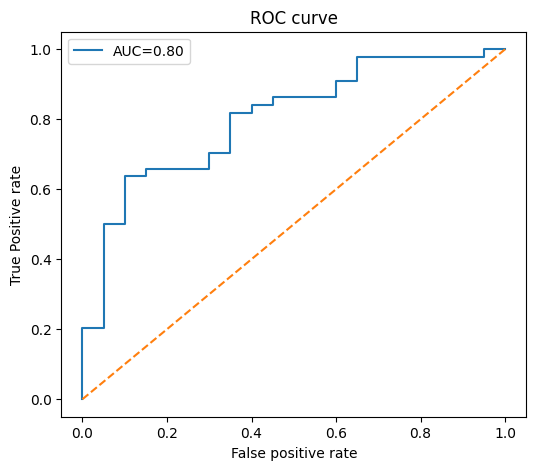

In [58]:
from sklearn.metrics import roc_curve,roc_auc_score
import matplotlib.pyplot as plt

#probability of fraud
y_prob=model.predict_proba(x_test_scaled)[:,1]

#ROC values
fpr,tpr,thresholds=roc_curve(y_test,y_prob)

#AUC
auc=roc_auc_score(y_test,y_prob)

print("AUC Score:",auc)

#plot ROC curve
plt.figure(figsize=(6,5))

plt.plot(fpr,tpr,label=f"AUC={auc:.2f}")
plt.plot([0,1],[0,1],linestyle="--")
plt.xlabel("False positive rate")
plt.ylabel("True Positive rate")
plt.title("ROC curve")
plt.legend()
plt.show()

In [59]:
"""Which provider characteristics contribute the most to predicting healthcare fraud?"""
coef=pd.DataFrame({
    "Feature":x_train.columns,
    "Coefficient":model.coef_[0]
})
coef=coef.sort_values(by="Coefficient",ascending=False)
print(coef)

                 Feature  Coefficient
3            total_reimb     0.665503
6             readmitted     0.448915
4  avg_reimb_per_patient     0.432717
0           total_claims     0.406268
2     claims_per_patient     0.392410
1         total_patients     0.315839
8    avg_chronic_disease    -0.101264
5       avg_length_ostay    -0.118001
7             readm_rate    -0.152529


In [60]:
#Random forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (confusion_matrix,accuracy_score,classification_report,roc_auc_score)
#model creation
rf_model=RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=5,
    random_state=1
)
#train model
rf_model.fit(x_train,y_train)
#predict
rf_pred=rf_model.predict(x_test)
#probabiities
rf_prob=rf_model.predict_proba(x_test)[:,1]
#evaluation
print("confusion_matrix")
print(confusion_matrix(y_test,rf_pred))
print("\nAccuracy")
print(accuracy_score(y_test,rf_pred))
print("\nclassification report")
print(classification_report(y_test,rf_pred))
print("\nAUC score")
print(roc_auc_score(y_test,rf_prob))


confusion_matrix
[[12  8]
 [ 7 37]]

Accuracy
0.765625

classification report
              precision    recall  f1-score   support

           0       0.63      0.60      0.62        20
           1       0.82      0.84      0.83        44

    accuracy                           0.77        64
   macro avg       0.73      0.72      0.72        64
weighted avg       0.76      0.77      0.76        64


AUC score
0.7772727272727272


In [61]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

rf=RandomForestClassifier(random_state=1)

param_grid = {
    'n_estimators':[100,200,300],
    'max_depth':[5,10,None],
    'min_samples_split':[2,5],
    'min_samples_leaf':[1,2]
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(x_train,y_train)
print("Best parameters" ,grid_search.best_params_)
print("Best cross validation score ",grid_search.best_score_)

Best parameters {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Best cross validation score  0.6877647058823528


In [62]:
best_rf=grid_search.best_estimator_
rf_pred=best_rf.predict(x_test)
rf_prob=best_rf.predict_proba(x_test)[:,1]

from sklearn.metrics import(
    confusion_matrix,
    accuracy_score,
    classification_report,
    roc_auc_score
)
print(confusion_matrix(y_test,rf_pred))
print(accuracy_score(y_test,rf_pred))
print(classification_report(y_test,rf_pred))
print(roc_auc_score(y_test,rf_prob))


[[11  9]
 [ 9 35]]
0.71875
              precision    recall  f1-score   support

           0       0.55      0.55      0.55        20
           1       0.80      0.80      0.80        44

    accuracy                           0.72        64
   macro avg       0.67      0.67      0.67        64
weighted avg       0.72      0.72      0.72        64

0.7636363636363636


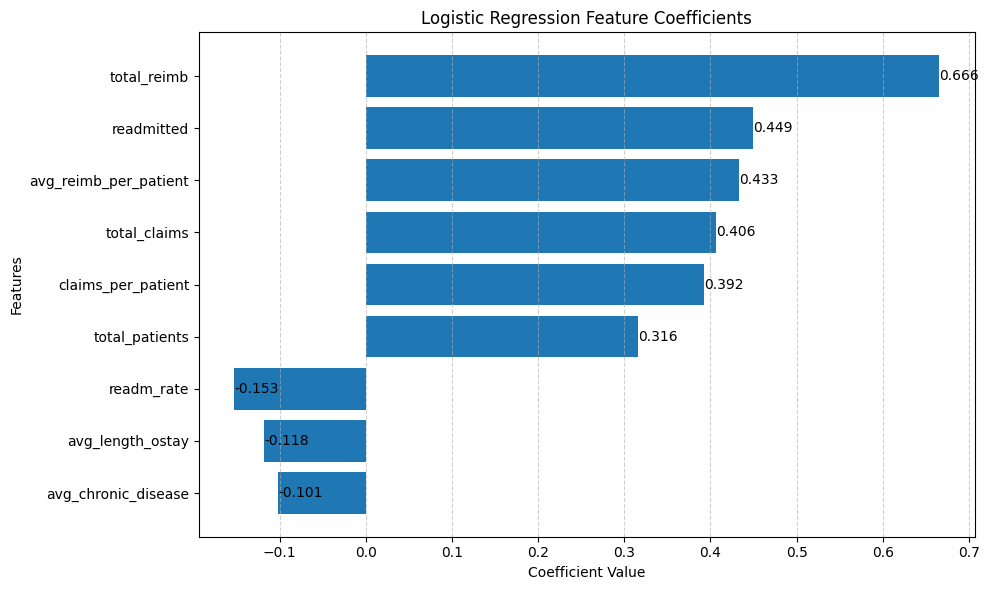

In [63]:
#Logistic Regression Feature Importance
import pandas as pd
import matplotlib.pyplot as plt

#feature name
features=x.columns

#logistic regression coefficients
coef=model.coef_[0]

#create dataframe
coef_df=pd.DataFrame({
    "Feature":features,
    "Coefficient":coef
})
#sort by absolute importance
coef_df["Abs_Coefficient"]=coef_df["Coefficient"].abs()
coef_df=coef_df.sort_values("Abs_Coefficient",ascending=True)

#Plot
plt.figure(figsize=(10,6))
plt.barh(coef_df["Feature"],coef_df["Coefficient"])

plt.title("Logistic Regression Feature Coefficients")
plt.xlabel("Coefficient Value")
plt.ylabel("Features")

plt.grid(axis="x",linestyle="--",alpha=0.6)
plt.tight_layout()

for i,v in enumerate(coef_df["Coefficient"]):
    plt.text(v,i,f"{v:.3f}",va="center")
plt.savefig("logistic_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

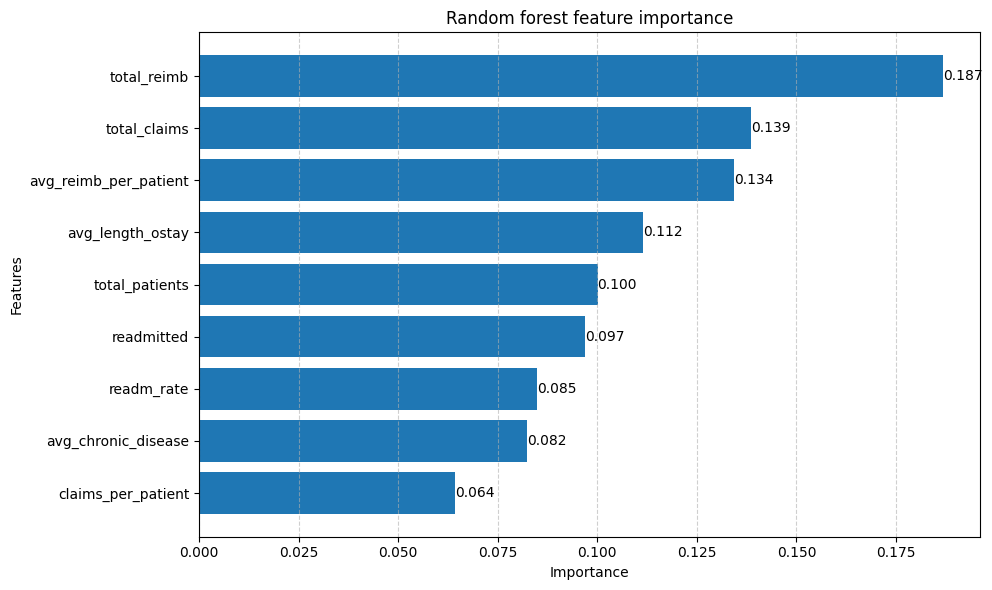

In [64]:
#Random Forest Feature Importance
import pandas as pd
import matplotlib.pyplot as plt

#feature importance
importance = best_rf.feature_importances_

rf_df=pd.DataFrame({
    "Feature":x.columns,
    "Importance":importance
})

rf_df=rf_df.sort_values("Importance",ascending=True)
plt.figure(figsize=(10,6))
plt.barh(rf_df["Feature"],rf_df["Importance"])
plt.title("Random forest feature importance")
plt.xlabel("Importance")
plt.ylabel("Features")

plt.grid(axis="x",linestyle="--",alpha=0.6)
plt.tight_layout()

for i,v in enumerate(rf_df["Importance"]):
    plt.text(v,i,f"{v:.3f}",va="center")
plt.savefig("random_forest_feature_importance.png", dpi=300, bbox_inches="tight") 
plt.show()

In [35]:
import joblib

joblib.dump(model,"fraud_model.pkl")
joblib.dump(scaler,"scaler.pkl")
print("Model saved successfully")

Model saved successfully


In [67]:
!pip install streamlit

  Using cached blinker-1.9.0-py3-none-any.whl.metadata (1.6 kB)
  Using cached toml-0.10.2-py2.py3-none-any.whl.metadata (7.1 kB)
  Using cached itsdangerous-2.2.0-py3-none-any.whl.metadata (1.9 kB)
  Using cached watchdog-6.0.0-py3-none-win_amd64.whl.metadata (44 kB)
  Using cached gitdb-4.0.12-py3-none-any.whl.metadata (1.2 kB)
   ---------------------------------------- 0.0/10.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.3 MB 326.8 kB/s eta 0:00:32
   ---------------------------------------- 0.0/10.3 MB 326.8 kB/s eta 0:00:32
   -----------------


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [65]:
import streamlit as st
import joblib
import numpy as np

ModuleNotFoundError: No module named 'streamlit'